Algorithm 1: Dijkstra's algorithm

 1: Import + Load Dataset

In [34]:
import pandas as pd
import numpy as np
import heapq
import time
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("distance_matrix_small (1).csv")

# Extract city names and distance matrix
city_names = df.iloc[:,0].tolist()
dist_matrix = df.iloc[:,1:].values

print("Cities:")
print(city_names)

print("\nDistance Matrix:")
print(dist_matrix)

Cities:
['Riyadh', 'Jeddah', 'Dammam', 'Mecca', 'Medina', 'Khobar', 'Abha', 'Tabuk', 'Hail']

Distance Matrix:
[[  0.          79.11154474 101.75689583  80.75256087  61.47276856
   40.55396403  96.28392236  78.0602175   27.74751791]
 [ 79.11154474   0.          22.67272864   6.9431789   24.11833434
   69.52925835  49.7024413   81.61753938  56.68628289]
 [101.75689583  22.67272864   0.          21.99504166  44.81230068
   90.23280556  54.35692679  96.45693214  78.63054666]
 [ 80.75256087   6.9431789   21.99504166   0.          29.63749943
   74.35879169  56.43239451  88.14772831  56.77513643]
 [ 61.47276856  24.11833434  44.81230068  29.63749943   0.
   45.60235909  41.91193972  59.81962493  45.41005557]
 [ 40.55396403  69.52925835  90.23280556  74.35879169  45.60235909
    0.          64.66538498  37.52290536  49.56879043]
 [ 96.28392236  49.7024413   54.35692679  56.43239451  41.91193972
   64.66538498   0.          50.56308795  86.14935838]
 [ 78.0602175   81.61753938  96.45693214  8

Explanation:

Loads the dataset and converts it into a distance matrix.

2: Dijkstra Algorithm

In [35]:
def dijkstra(matrix, start):
    n = len(matrix)

    distances = [float('inf')] * n
    distances[start] = 0

    visited = [False] * n
    queue = [(0, start)]

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        if visited[current_node]:
            continue

        visited[current_node] = True

        for neighbor in range(n):
            weight = matrix[current_node][neighbor]

            if weight > 0:
                new_distance = current_distance + weight

                if new_distance < distances[neighbor]:
                    distances[neighbor] = new_distance
                    heapq.heappush(queue, (new_distance, neighbor))

    return distances

Explanation:

Implements Dijkstra's algorithm to find shortest paths.

Time complexity:

O((V+E)logV)

3: Run Algorithm

In [36]:
result = dijkstra(dist_matrix, 0)

print("Shortest distances from Riyadh:\n")

for i, distance in enumerate(result):
    print(f"{city_names[i]}: {distance:.2f} km")

Shortest distances from Riyadh:

Riyadh: 0.00 km
Jeddah: 79.11 km
Dammam: 101.76 km
Mecca: 80.75 km
Medina: 61.47 km
Khobar: 40.55 km
Abha: 96.28 km
Tabuk: 78.06 km
Hail: 27.75 km


Explanation:

Runs the algorithm using Riyadh as the starting city.

4 : Small Input Testing

In [37]:
small_sizes = [4,6,8]
small_times = []

print("Small Input Testing")

for size in small_sizes:
    matrix = dist_matrix[:size,:size]

    start = time.time()
    dijkstra(matrix,0)
    end = time.time()

    runtime = end-start
    small_times.append(runtime)

    print(f"Input Size {size}: {runtime:.6f} seconds")

Small Input Testing
Input Size 4: 0.000061 seconds
Input Size 6: 0.000068 seconds
Input Size 8: 0.000107 seconds


Explanation:
Tests smaller datasets using real city data.

5 :Small Input Graph

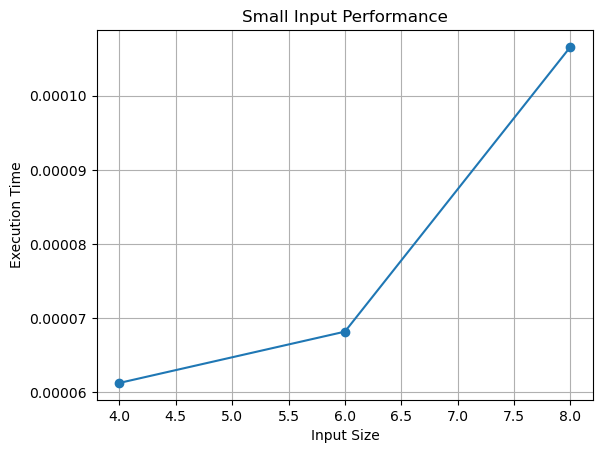

In [38]:
plt.plot(small_sizes, small_times, marker='o')

plt.title("Small Input Performance")
plt.xlabel("Input Size")
plt.ylabel("Execution Time")
plt.grid(True)
plt.show()

Shows performance for small datasets.

6: Best Case (Small)

In [39]:
best_small = dist_matrix[:4,:4]

start = time.time()
dijkstra(best_small,0)
end = time.time()

best_small_time = end-start

print("Best Small Case Time:", best_small_time)

Best Small Case Time: 0.00037217140197753906


Explanation:

Represents the smallest real dataset.

7: Average Case (Small)

In [40]:
avg_small = dist_matrix[:6,:6]

start = time.time()
dijkstra(avg_small,0)
end = time.time()

avg_small_time = end-start

print("Average Small Case Time:", avg_small_time)

Average Small Case Time: 0.0002961158752441406


Explanation:

Represents medium-sized real dataset.

8: Worst Case (Small)

In [41]:
worst_small = dist_matrix[:8,:8]

start = time.time()
dijkstra(worst_small,0)
end = time.time()

worst_small_time = end-start

print("Worst Small Case Time:", worst_small_time)

Worst Small Case Time: 0.00026988983154296875


Explanation:

Represents the largest real subset.

9: Small Case Graph

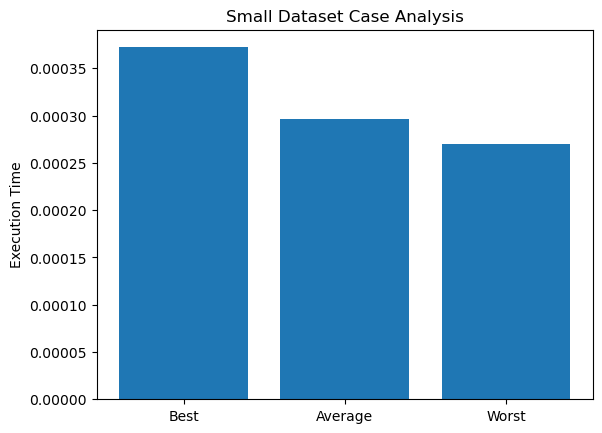

In [42]:
case_names = ["Best","Average","Worst"]
case_times = [best_small_time, avg_small_time, worst_small_time]

plt.bar(case_names, case_times)

plt.title("Small Dataset Case Analysis")
plt.ylabel("Execution Time")
plt.show()

Explanation:
This graph shows the execution time of Dijkstra's algorithm for best, average, and worst cases using small input sizes. It demonstrates how runtime increases as the number of cities grows.

10 : Large Input Testing

In [43]:
large_sizes = [20,40,60]
large_times = []

print("Large Input Testing")

for size in large_sizes:
    matrix = np.random.randint(1,100,(size,size))
    np.fill_diagonal(matrix,0)

    start = time.time()
    dijkstra(matrix,0)
    end = time.time()

    runtime = end-start
    large_times.append(runtime)

    print(f"Input Size {size}: {runtime:.6f} seconds")

Large Input Testing
Input Size 20: 0.000633 seconds
Input Size 40: 0.001904 seconds
Input Size 60: 0.003991 seconds


Explanation:
Tests larger datasets to evaluate scalability.

11 : Large Input Graph

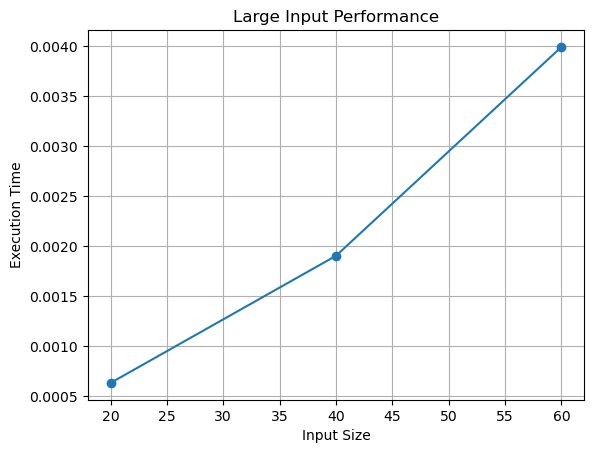

In [44]:
plt.plot(large_sizes, large_times, marker='o')

plt.title("Large Input Performance")
plt.xlabel("Input Size")
plt.ylabel("Execution Time")
plt.grid(True)
plt.show()

Explanation:

Shows runtime growth for larger datasets.

12: Best Case (Large Input)

In [45]:
best_large = np.random.randint(1,100,(20,20))
np.fill_diagonal(best_large,0)

start = time.time()
dijkstra(best_large,0)
end = time.time()

best_time = end-start

print("Best Case Time:", best_time)

Best Case Time: 0.0010216236114501953


Explanation:

Represents the minimum workload for large datasets.

13 :Average Case (Large Input)

In [46]:
avg_large = np.random.randint(1,100,(40,40))
np.fill_diagonal(avg_large,0)

start = time.time()
dijkstra(avg_large,0)
end = time.time()

avg_time = end-start

print("Average Case Time:", avg_time)

Average Case Time: 0.002598285675048828


Explanation:

Represents average workload

14 : Worst Case (Large Input)

In [47]:
worst_large = np.random.randint(1,100,(60,60))
np.fill_diagonal(worst_large,0)

start = time.time()
dijkstra(worst_large,0)
end = time.time()

worst_time = end-start

print("Worst Case Time:", worst_time)

Worst Case Time: 0.0052814483642578125


Explanation:

Represents maximum workload

15 :Large Case Graph

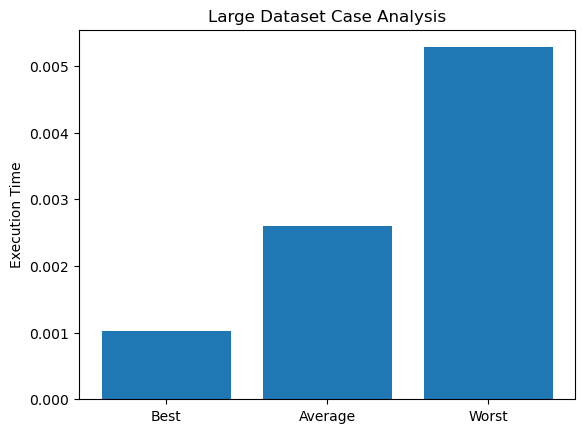

In [49]:
case_names = ["Best", "Average", "Worst"]
case_times = [best_time, avg_time, worst_time]

plt.bar(case_names, case_times)

plt.title("Large Dataset Case Analysis")
plt.ylabel("Execution Time")
plt.show()

Explanation:

This graph compares best, average, and worst cases for large datasets and shows how execution time increases as the input size grows.

16 :Final Comparison Code

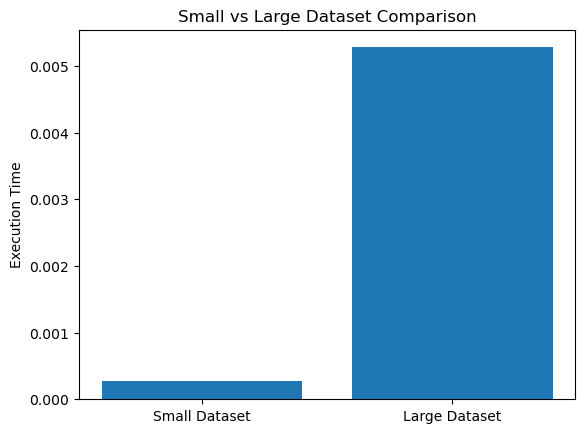

In [50]:
comparison_names = ["Small Dataset", "Large Dataset"]
comparison_times = [worst_small_time, worst_time]

plt.bar(comparison_names, comparison_times)

plt.title("Small vs Large Dataset Comparison")
plt.ylabel("Execution Time")
plt.show()

Shows how runtime increases as input size grows.

Explanation:
This graph compares the performance of Dijkstra's algorithm on small and large datasets. The small dataset requires less computation, so the execution time is lower, while the large dataset takes longer because it contains more cities and requires more calculations. This demonstrates how the algorithm’s runtime increases as the input size grows.